In [1]:
import numpy as np
import tensorflow as tf
import glob
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

from tensorflow.keras.layers import Conv2D,Dense,AveragePooling2D,Flatten
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import Sequential,load_model
import matplotlib.pyplot as plt
import cv2
import os
from matplotlib.image import imread
%matplotlib inline

# visualize Cat Images

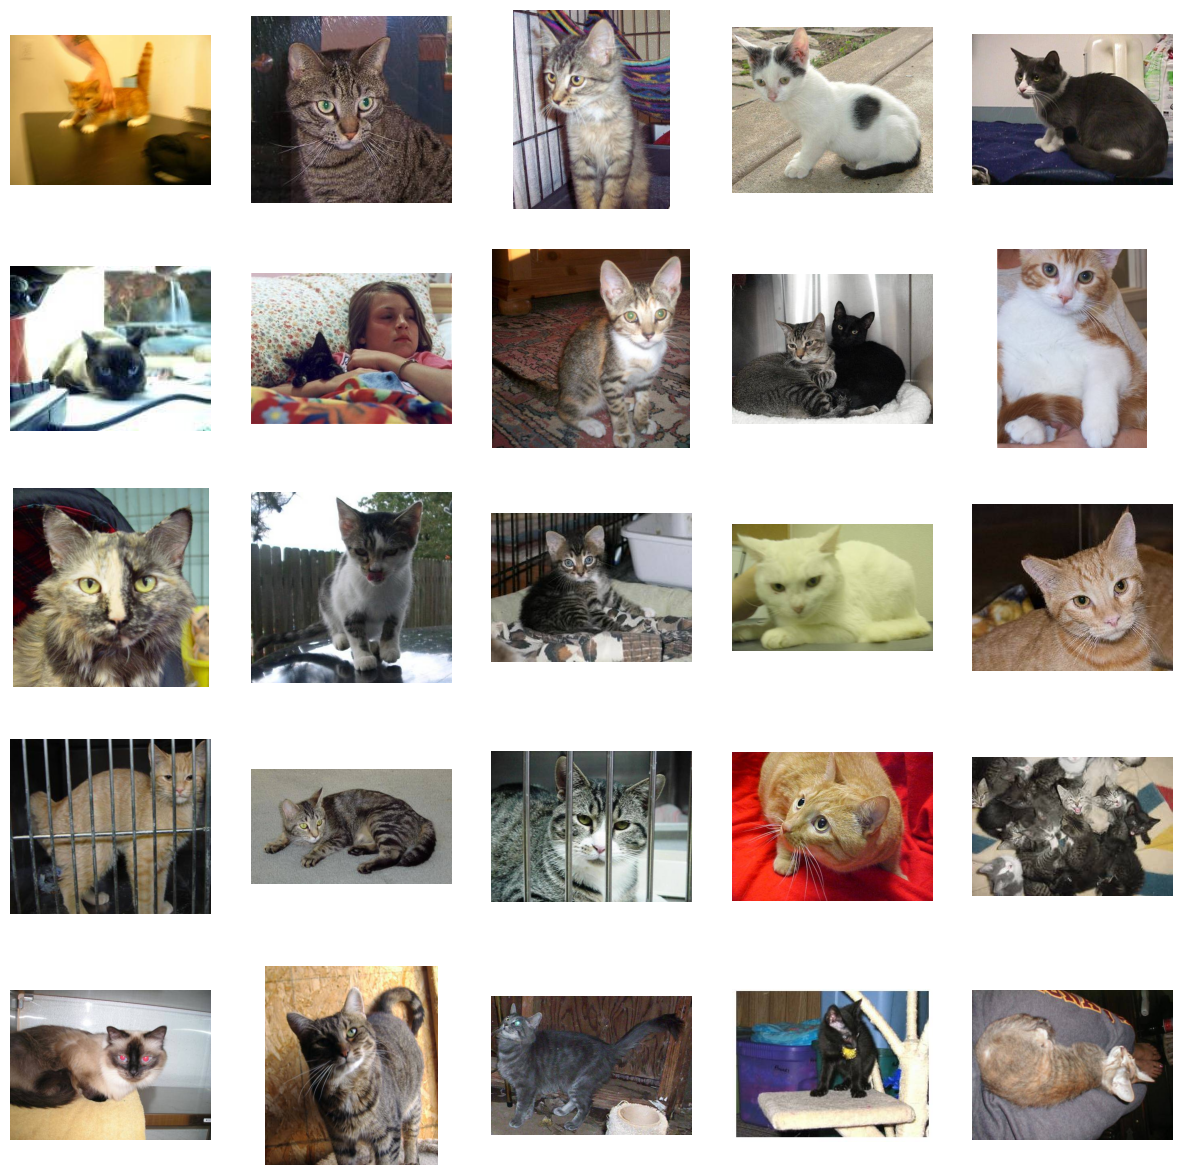

In [2]:
cat_images="../input/dogs-vs-cats/train/train/"
plt.figure(figsize=(15,15))

for i in range(25):
    plt.subplot(5,5,i+1)

    file_name=cat_images+"cat."+str(i)+".jpg"
    load_image=imread(file_name)
    plt.imshow(load_image)
    plt.axis("off")

plt.show()

# Visualize Dog Images

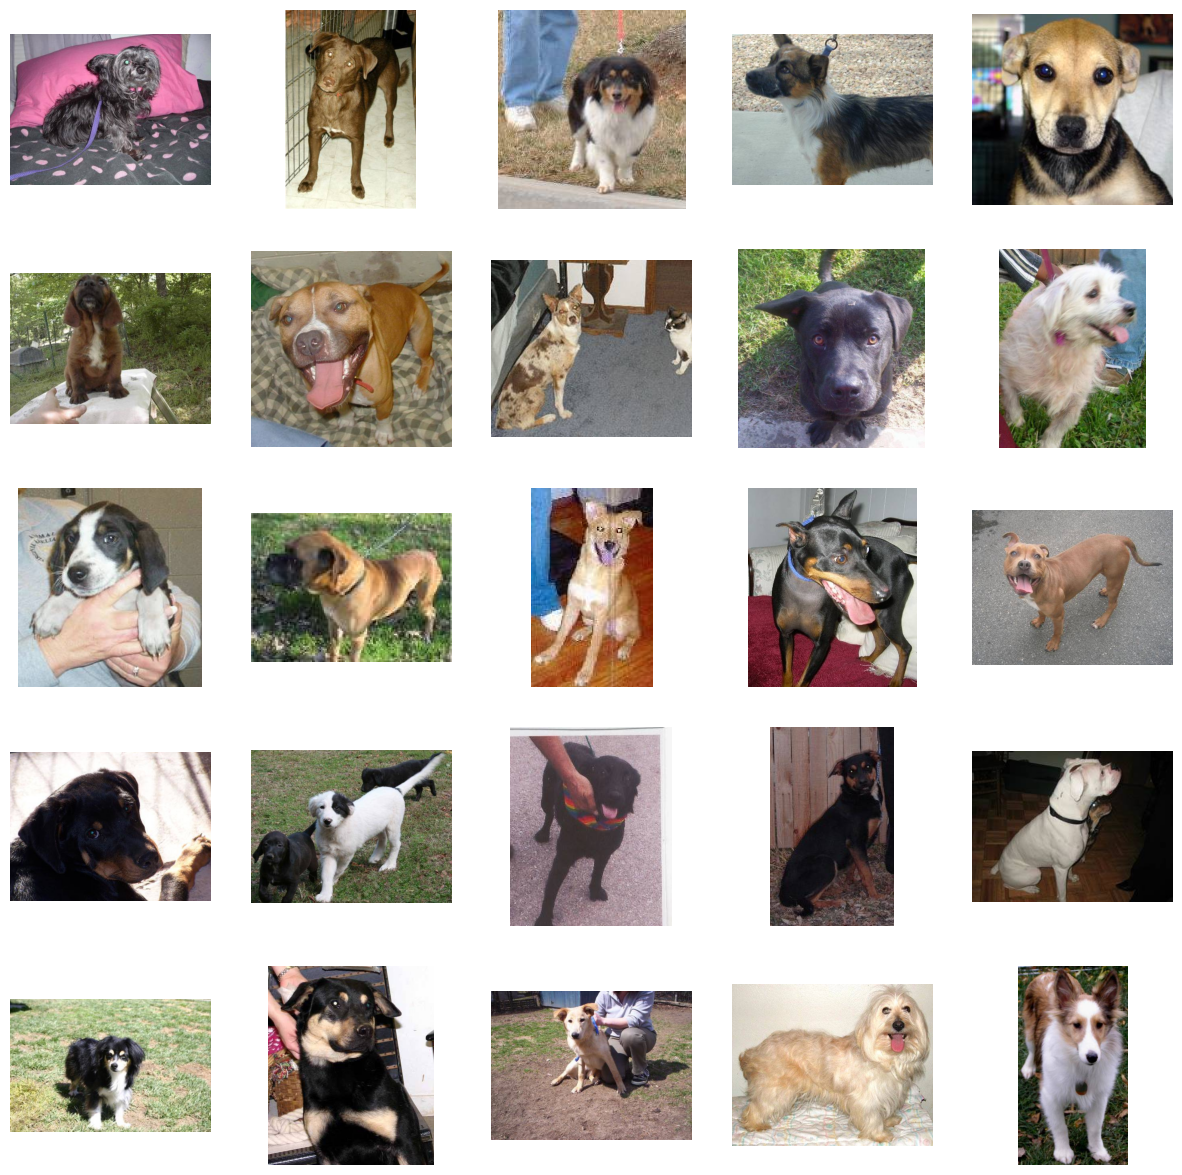

In [3]:

dog_images="../input/dogs-vs-cats/train/train/"

plt.figure(figsize=(15,15))
for i in range(25):
    plt.subplot(5,5,i+1)

    file_name=dog_images+"dog."+str(i)+".jpg"
    load_image=imread(file_name)
    plt.imshow(load_image)
    plt.axis("off")

plt.show()

In [4]:
test_image_path="/kaggle/input/dogs-vs-cats/train/train/"

In [5]:
check_items=os.listdir(test_image_path)

In [6]:
np.unique(check_items)

array(['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', ..., 'dog.9997.jpg',
       'dog.9998.jpg', 'dog.9999.jpg'], dtype='<U13')

In [7]:
check_items.index("dog.9997.jpg")

4871

In [8]:
check_items[997]

'cat.8699.jpg'

In [9]:
image_width=28
image_height=28

In [10]:
def imagefeatureextract(image,size=(28,28)):
    
    
    img=cv2.resize(image,size)
    gray=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
    gray=np.expand_dims(gray,2)
    return gray

In [11]:
#imagefeatureextract(test_image_one)

In [12]:
test_image_path="/kaggle/input/dogs-vs-cats/train/train/"

In [13]:
dataset_path=os.path.join(test_image_path,"*g")
file_read=glob.glob(dataset_path)

In [14]:
data=[]
category=[]
for(i,file) in enumerate(file_read):
  image=cv2.imread(file)
  feature=imagefeatureextract(image)
  data.append(feature)
  classnames=file.split(os.path.sep)[-1].split(".")[0]
  category.append(classnames)
 
 

   

In [15]:
data =np.array(data,dtype=np.uint8)
labels=np.array(category)

In [16]:
data.shape

(25000, 28, 28, 1)

In [17]:
np.unique(category)

array(['cat', 'dog'], dtype='<U3')

In [18]:
len(data)

25000

In [19]:
len(category)

25000

# Label Encoder

In [20]:
labels=np.array(category)

In [21]:
label_encoder=preprocessing.LabelEncoder()
#label_encoder=LabelEncoder()

In [22]:
classnames=label_encoder.fit_transform(labels)

In [23]:
np.unique(classnames)

array([0, 1])

In [24]:
classnames.shape

(25000,)

In [25]:
classnames[0]

0

# ONE_HOT_ENCODING

In [26]:
onehotencoder=OneHotEncoder(sparse=False)
label_Encoder_value=classnames.reshape(len(classnames),1)
oneHotEncoder_Values=onehotencoder.fit_transform(label_Encoder_value)

/opt/conda/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [27]:
oneHotEncoder_Values

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [28]:
X_train,X_test,Y_train,Y_test=train_test_split(data,oneHotEncoder_Values,test_size=0.2,random_state=42)

In [29]:
model = Sequential()

# 1st layer
model.add(Conv2D(6, kernel_size=(5,5), strides=(1,1), activation="tanh", input_shape=(28,28,1), padding="same"))
model.add(AveragePooling2D(pool_size=(2,2), strides=(2,2), padding="valid"))

# 2nd layer
model.add(Conv2D(16, kernel_size=(5,5), strides=(1,1), activation="tanh", padding="valid"))
model.add(AveragePooling2D(pool_size=(2,2), strides=(2,2), padding="valid"))

model.add(Flatten())

model.add(Dense(120, activation="tanh"))
model.add(Dense(84, activation="tanh"))
model.add(Dense(2, activation="softmax"))

from tensorflow.keras.optimizers import Adam

learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,026 (238.38 KB)

 Trainable params: 61,026 (238.38 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history=model.fit(X_train,Y_train,epochs=30,validation_data=(X_test,Y_test),verbose=1)

Epoch 1/30


I0000 00:00:1725383713.001964    4765 service.cc:145] XLA service 0x7fd428007a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1725383713.002027    4765 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 73/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5318 - loss: 0.7329

I0000 00:00:1725383715.120823    4765 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5553 - loss: 0.6933 - val_accuracy: 0.6300 - val_loss: 0.6440
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6406 - loss: 0.6358 - val_accuracy: 0.6600 - val_loss: 0.6165
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6684 - loss: 0.6073 - val_accuracy: 0.6772 - val_loss: 0.6047
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6877 - loss: 0.5850 - val_accuracy: 0.6902 - val_loss: 0.5886
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6896 - loss: 0.5815 - val_accuracy: 0.6922 - val_loss: 0.5893
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7103 - loss: 0.5596 - val_accuracy: 0.6980 - val_loss: 0.5791
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7190 - loss: 0.5473 - val_accuracy: 0.6944 - val_loss: 0.5776
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7310 - loss: 0.5339 - val_accuracy: 0.6944 - val_

In [31]:
class_data=["cat","dog"]

In [32]:

test_image_data=cv2.imread("/kaggle/input/dogs-vs-cats/train/train/cat.100.jpg")


In [33]:
image_feature=imagefeatureextract(test_image_data)/255.0
image_feature=np.array([image_feature])

In [34]:
image_feature.shape

(1, 28, 28, 1)

In [35]:
predict=model.predict(image_feature)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


In [36]:
probability=model.predict(image_feature)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [37]:
maximum_probability=predict.argmax(axis=0)

In [38]:
maximum_probability

0

In [39]:
imagedatalabels="{}: {:.2f}%".format(class_data[maximum_probability],predict[maximum_probability]*100)

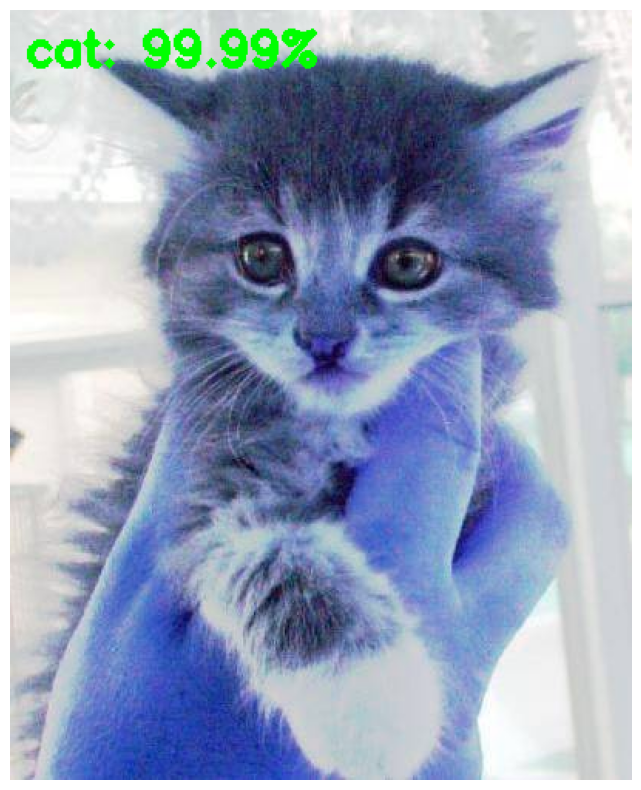

In [40]:

plt.figure(figsize=(10,10))
cv2.putText(test_image_data,imagedatalabels,(10,35),cv2.FONT_HERSHEY_SIMPLEX,1.0,(0,255,0),3)
plt.imshow(test_image_data,cmap="gray")
plt.axis("off")
plt.show()

In [41]:
from sklearn.metrics import (
    accuracy_score,          # Accuracy classification score
    roc_auc_score,           # Compute the area under the receiver operating characteristic (ROC) curve
    brier_score_loss,        # Brier score loss for binary classification
    cohen_kappa_score,       # Cohen's kappa statistic
    matthews_corrcoef,       # Matthews correlation coefficient
    log_loss,                # Log loss (cross-entropy loss)
    classification_report,   # Build a text report showing the main classification metrics
    confusion_matrix,        # Compute confusion matrix to evaluate the accuracy of a classification
    f1_score,                # Compute the F1 score, the harmonic mean of precision and recall
    precision_score,         # Compute the precision score
    recall_score,            # Compute the recall score
    average_precision_score, # Compute average precision score
    precision_recall_curve,  # Compute precision-recall pairs for different probability thresholds
    roc_curve                # Compute Receiver operating characteristic (ROC) curve
)




In [42]:
pred=model.predict(X_test)
predict=np.argmax(pred,axis=1)
Y_test=np.argmax(Y_test,axis=1)
label_name=["cat","dog"]

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


# Confusion Matrix

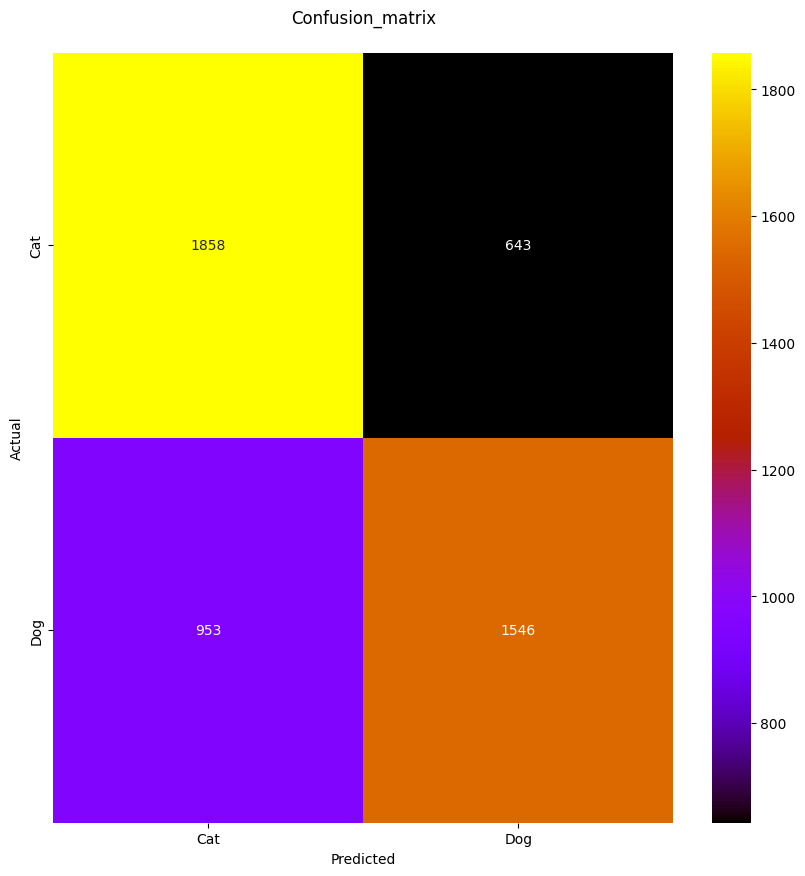

In [43]:
plt.figure(figsize=(10,10))
import seaborn as sns
label_name=["Cat","Dog"]
cm = confusion_matrix(Y_test,predict)
sns.heatmap(cm,  annot=True, fmt="d" ,cmap="gnuplot",xticklabels=label_name,yticklabels=label_name)
plt.title("Confusion_matrix\n")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report

In [44]:
print(classification_report(Y_test,predict,target_names=label_name))

              precision    recall  f1-score   support

         Cat       0.66      0.74      0.70      2501
         Dog       0.71      0.62      0.66      2499

    accuracy                           0.68      5000
   macro avg       0.68      0.68      0.68      5000
weighted avg       0.68      0.68      0.68      5000



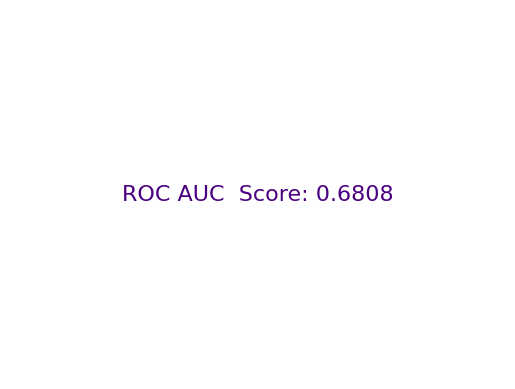

In [45]:
roc_auc = roc_auc_score(Y_test, predict)
plt.plot([])
plt.text(0,0, f'ROC AUC  Score: {roc_auc:.4f}', fontsize=16, ha='center', va='center',color="indigo")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

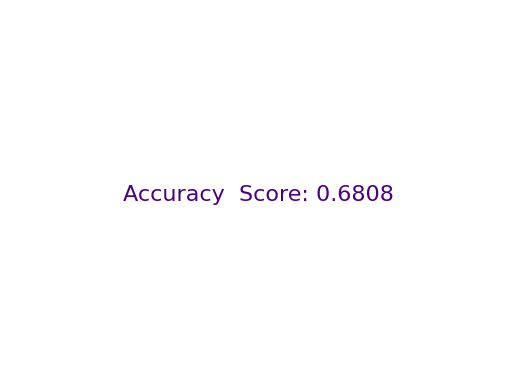

In [46]:
acc= accuracy_score(Y_test, predict)
plt.plot([])
plt.text(0,0, f'Accuracy  Score: {acc:.4f}', fontsize=16, ha='center', va='center',color="indigo")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

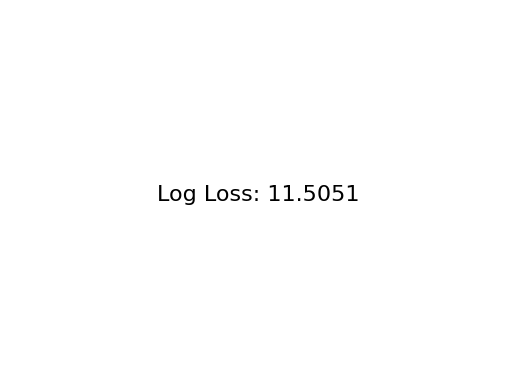

In [47]:
logarithm_loss=log_loss(Y_test,predict)
plt.plot([])
plt.text(0,0, f'Log Loss: {logarithm_loss:.4f}', fontsize=16, ha='center', va='center',color="black")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

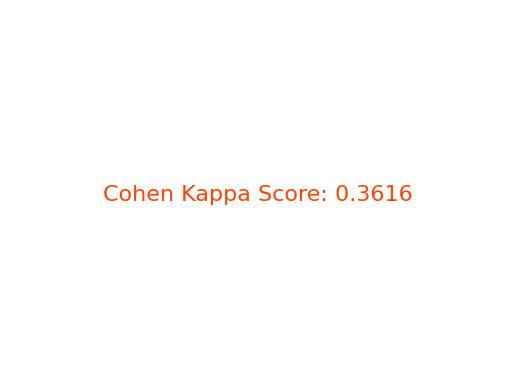

In [48]:
kappa = cohen_kappa_score(Y_test,predict)
plt.plot([])
plt.text(0,0, f'Cohen Kappa Score: {kappa:.4f}', fontsize=16, ha='center', va='center',color="orangered")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

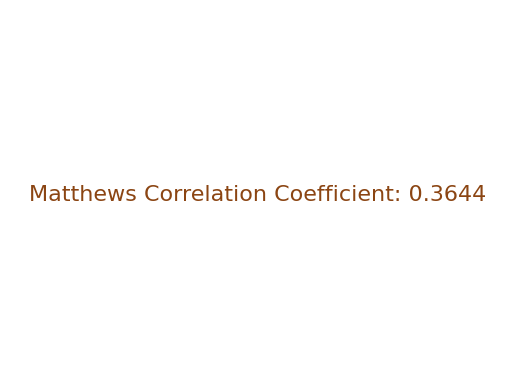

In [49]:
mcc = matthews_corrcoef(Y_test,predict)

# Create a plot and display the MCC value as text
plt.plot([])
plt.text(0,0, f'Matthews Correlation Coefficient: {mcc:.4f}', fontsize=16, ha='center', va='center',color="saddlebrown")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

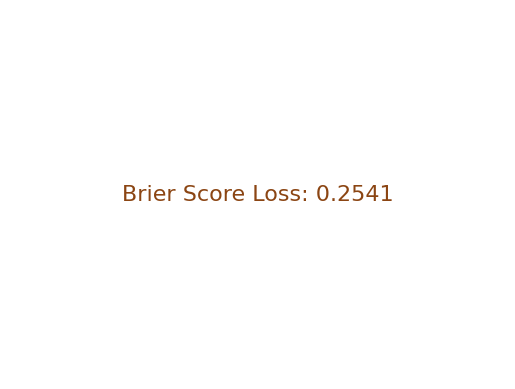

In [50]:

from sklearn.metrics import brier_score_loss

Y_test_labels = np.argmax(Y_test, axis=1) if Y_test.ndim > 1 else Y_test
brier_loss = brier_score_loss(Y_test_labels, pred[:, 1])

plt.plot([])
plt.text(0, 0, f'Brier Score Loss: {brier_loss:.4f}', fontsize=16, ha='center', va='center', color="saddlebrown")
plt.axis('off')
plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.show()


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


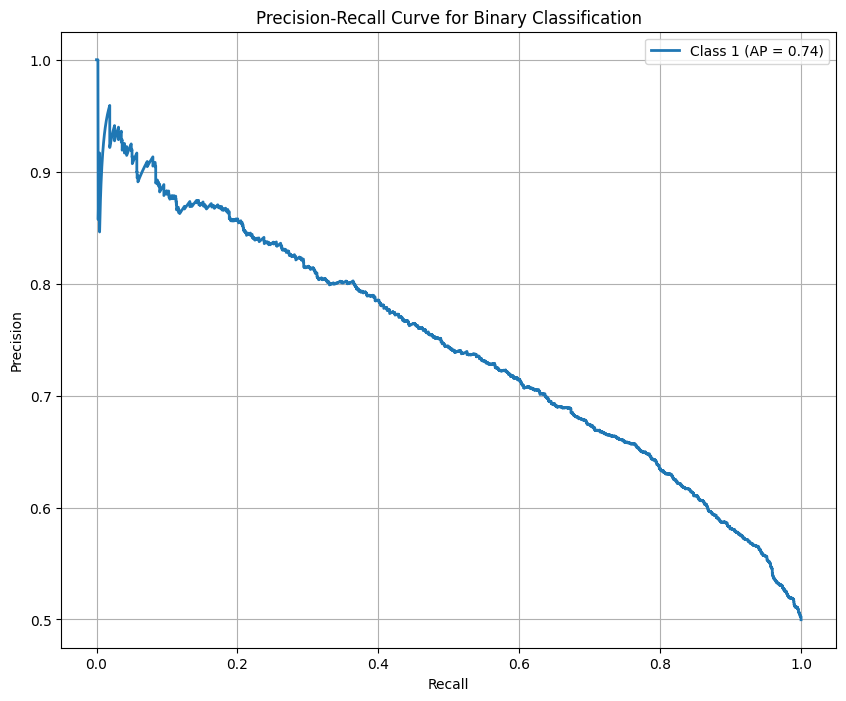

In [51]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

predict_probs = model.predict(X_test)
num_classes = predict_probs.shape[1]
Y_test_binarized = label_binarize(Y_test, classes=np.arange(num_classes))

plt.figure(figsize=(10, 8))

precision, recall, _ = precision_recall_curve(Y_test_binarized[:, 0], predict_probs[:, 1])
average_precision = average_precision_score(Y_test_binarized[:, 0], predict_probs[:, 1])
plt.plot(recall, precision, lw=2, label=f'Class 1 (AP = {average_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Binary Classification')
plt.legend(loc='best')
plt.grid(True)
plt.show()


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


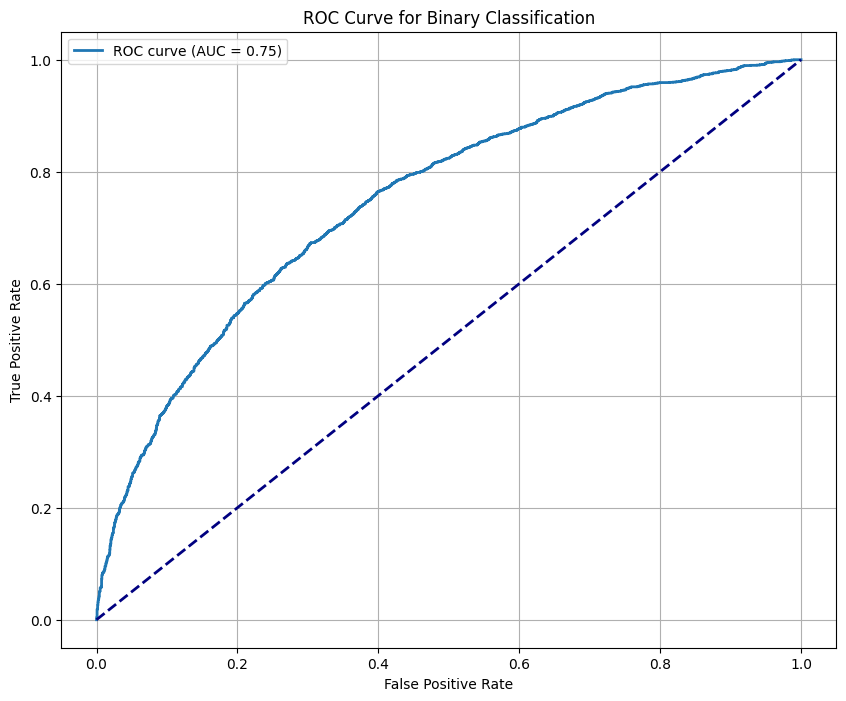

In [52]:
from sklearn.metrics import roc_curve, roc_auc_score


predict_probs = model.predict(X_test)
num_classes = predict_probs.shape[1]
Y_test_binarized = label_binarize(Y_test, classes=np.arange(num_classes))

plt.figure(figsize=(10, 8))

fpr, tpr, _ = roc_curve(Y_test_binarized[:, 0], predict_probs[:, 1])
roc_auc = roc_auc_score(Y_test_binarized[:, 0], predict_probs[:, 1])
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Binary Classification')
plt.legend(loc='best')
plt.grid(True)
plt.show()


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


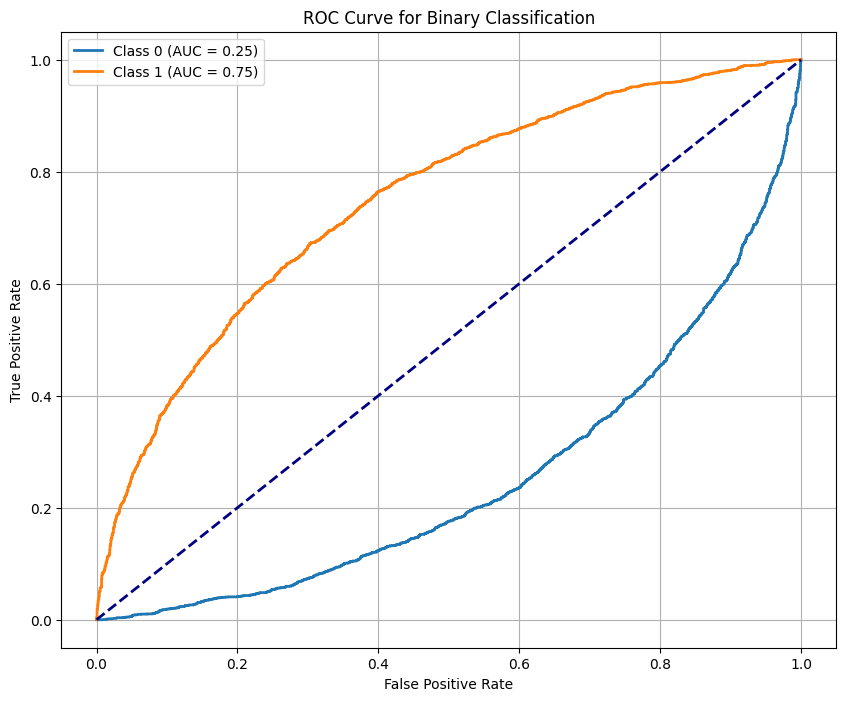

In [53]:


predict_probs = model.predict(X_test)
num_classes = predict_probs.shape[1]  # Should be 2 for binary classification
Y_test_binarized = label_binarize(Y_test, classes=np.arange(num_classes))

plt.figure(figsize=(10, 8))

# For Class 0
fpr0, tpr0, _ = roc_curve(Y_test_binarized[:, 0], predict_probs[:, 0])
roc_auc0 = roc_auc_score(Y_test_binarized[:, 0], predict_probs[:, 0])
plt.plot(fpr0, tpr0, lw=2, label=f'Class 0 (AUC = {roc_auc0:.2f})')

# For Class 1
fpr1, tpr1, _ = roc_curve(Y_test_binarized[:, 0], predict_probs[:, 1])
roc_auc1 = roc_auc_score(Y_test_binarized[:, 0], predict_probs[:, 1])
plt.plot(fpr1, tpr1, lw=2, label=f'Class 1 (AUC = {roc_auc1:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Binary Classification')
plt.legend(loc='best')
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


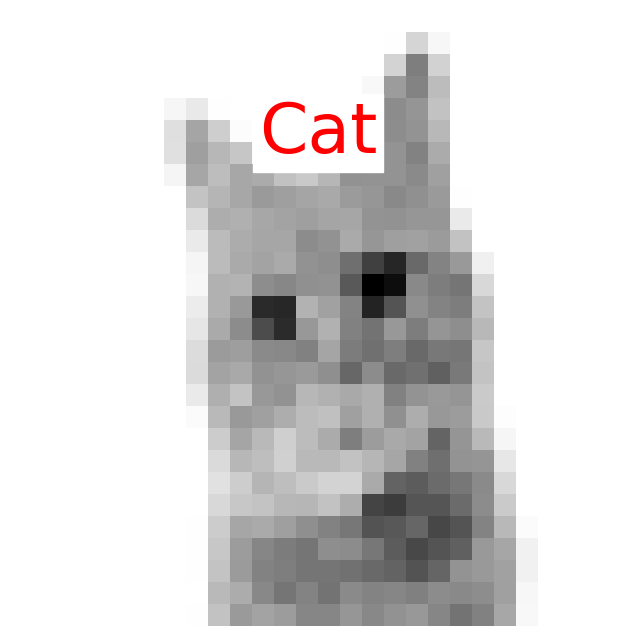

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
import tensorflow as tf
plt.figure(figsize=(10,8))
# Load image from URL
image_url = "https://st2.depositphotos.com/1000938/5499/i/450/depositphotos_54998613-stock-photo-ginger-cat.jpg"
response = requests.get(image_url)
test_image_path = Image.open(BytesIO(response.content))

# Resize the image to 28x28
height, width = 28,28
imge = test_image_path.convert('L').resize((width, height))  # Convert to grayscale and resize
imge = np.array(imge) / 255.0  # Normalize pixel values
imge = np.expand_dims(imge, axis=-1)  # Add channel dimension
imge = np.expand_dims(imge, axis=0)  # Add batch dimension

# Predict with model
prediction = model.predict(imge)
final_predict = np.argmax(prediction[0])

label_name = ["Cat", "Dog"]  # Adjust labels if needed
label = label_name[final_predict]

# Plot image with prediction label
plt.imshow(np.squeeze(imge), cmap='gray')  # Display grayscale image
plt.axis("off")
plt.text(0.5, 0.8, label, color='red', fontsize=50, backgroundcolor='white',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes)
plt.show()
